# **INGEST**

In [12]:
import pandas as pd

In [13]:
%cd /content/DS-01

/content/DS-01


# **2) Perform the 5 data visualization tasks**

In [14]:
df1 = pd.read_csv('data/raw_data/StudentsPerformance.csv')
df1

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [15]:
df1.columns = df1.columns.str.replace(' ', '_')
df1

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [16]:
print(df1.isnull().sum())

gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [23]:
df1.to_csv('data/cleaned_data/StudentsPerformance.csv', index=False)

The box plots reveal that there are some differences between the two genders in math and reading skills. The median scores of female students in reading are higher than those of male students. The interquartile range of reading scores for female students is slightly smaller, which means that there is more consistency in their scores. The median scores of male and female students in math are relatively similar, but the male students tend to have slightly more variability. The distribution of scores indicates that the differences in reading skills are more marked than those in math skills. There are some outliers for both genders, but the shapes of the distributions are similar.

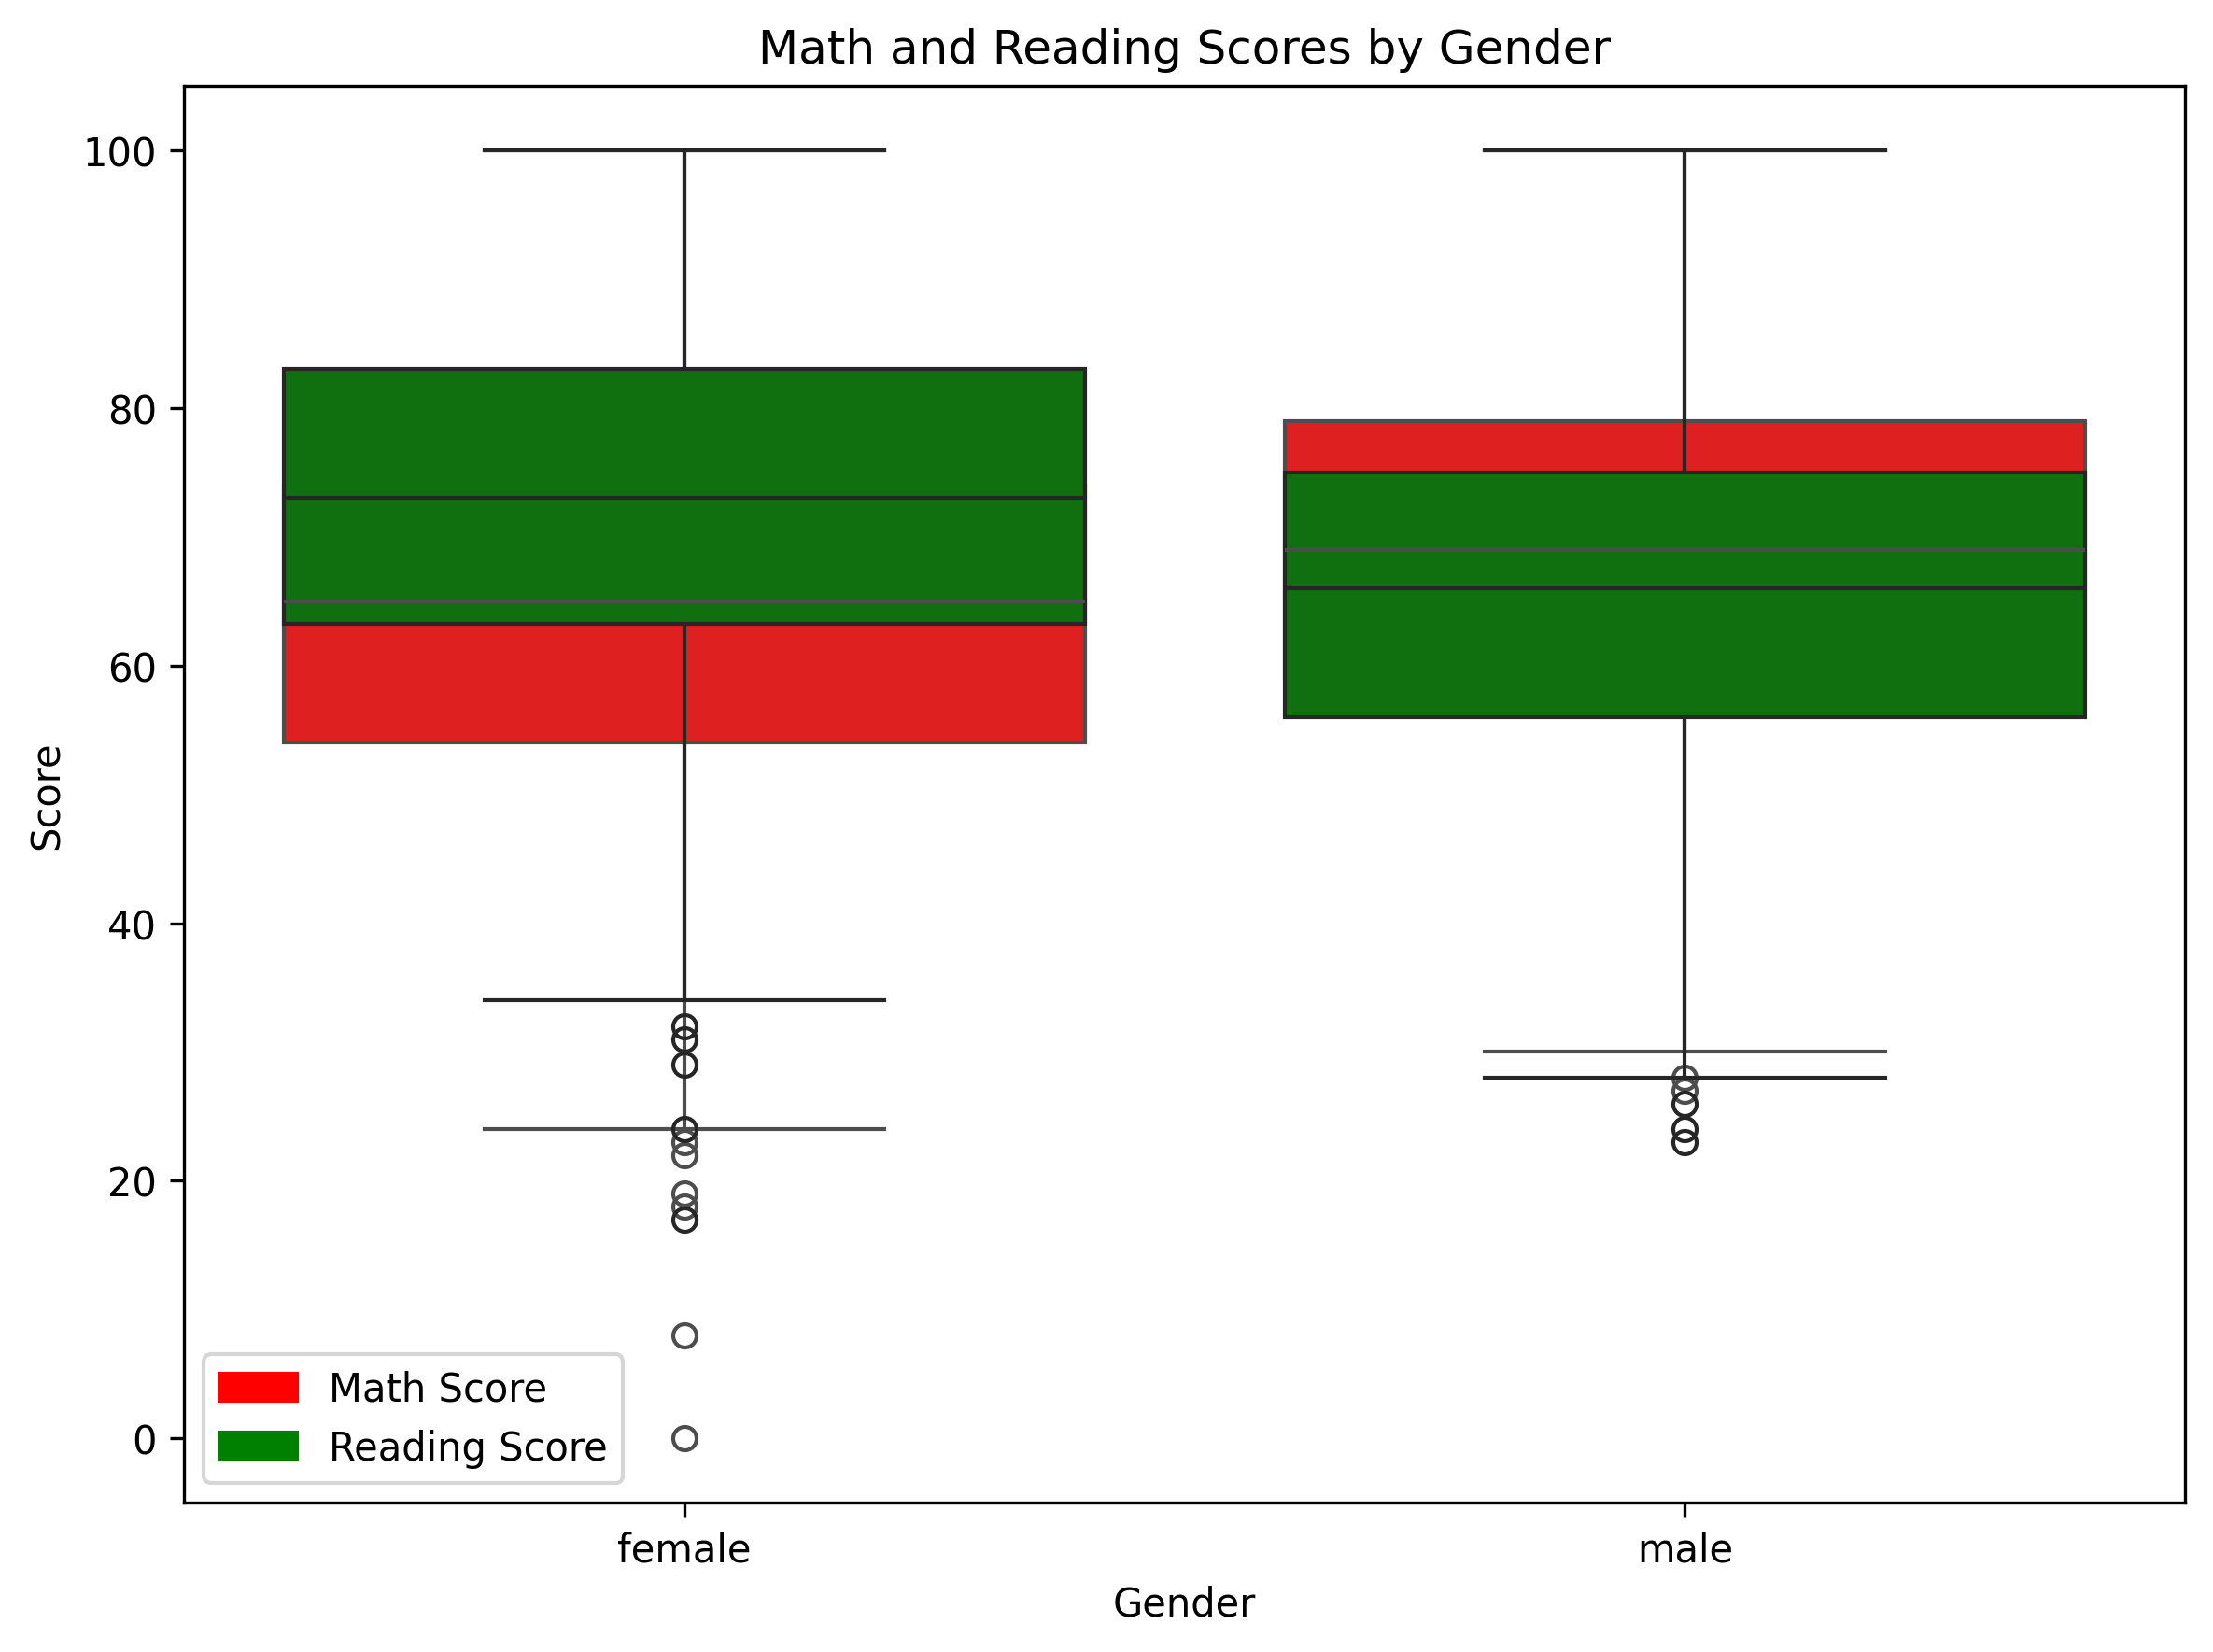

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as pth

plt.figure(figsize=(8,6), dpi=300)
sns.boxplot(x="gender", y="math_score", data=df1, color ="red")
sns.boxplot(x="gender", y="reading_score", data=df1, color="green")
math = pth.Patch(color='red', label='Math Score')
reading = pth.Patch(color='green', label='Reading Score')

plt.legend(handles=[math, reading])

plt.title("Math and Reading Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("figures/V1_gender_boxplots.png")
plt.show()
plt.close()


We are checking the Math score of people who have completed the test preparation course and those who did not do it. We can see clear difference in median is higher when people completed the test preparation course and it says that the course is helpful to students generally to score good. The range of completed students seems to be slightly reduced. This indicates that preparation for tests has a positive effect on student performance in mathematics. While it is not necessarily true that all students are affected equally, it appears to be true for all students that completing the test has a positive effect. Thus, it appears that there is a positive association based on the chart.

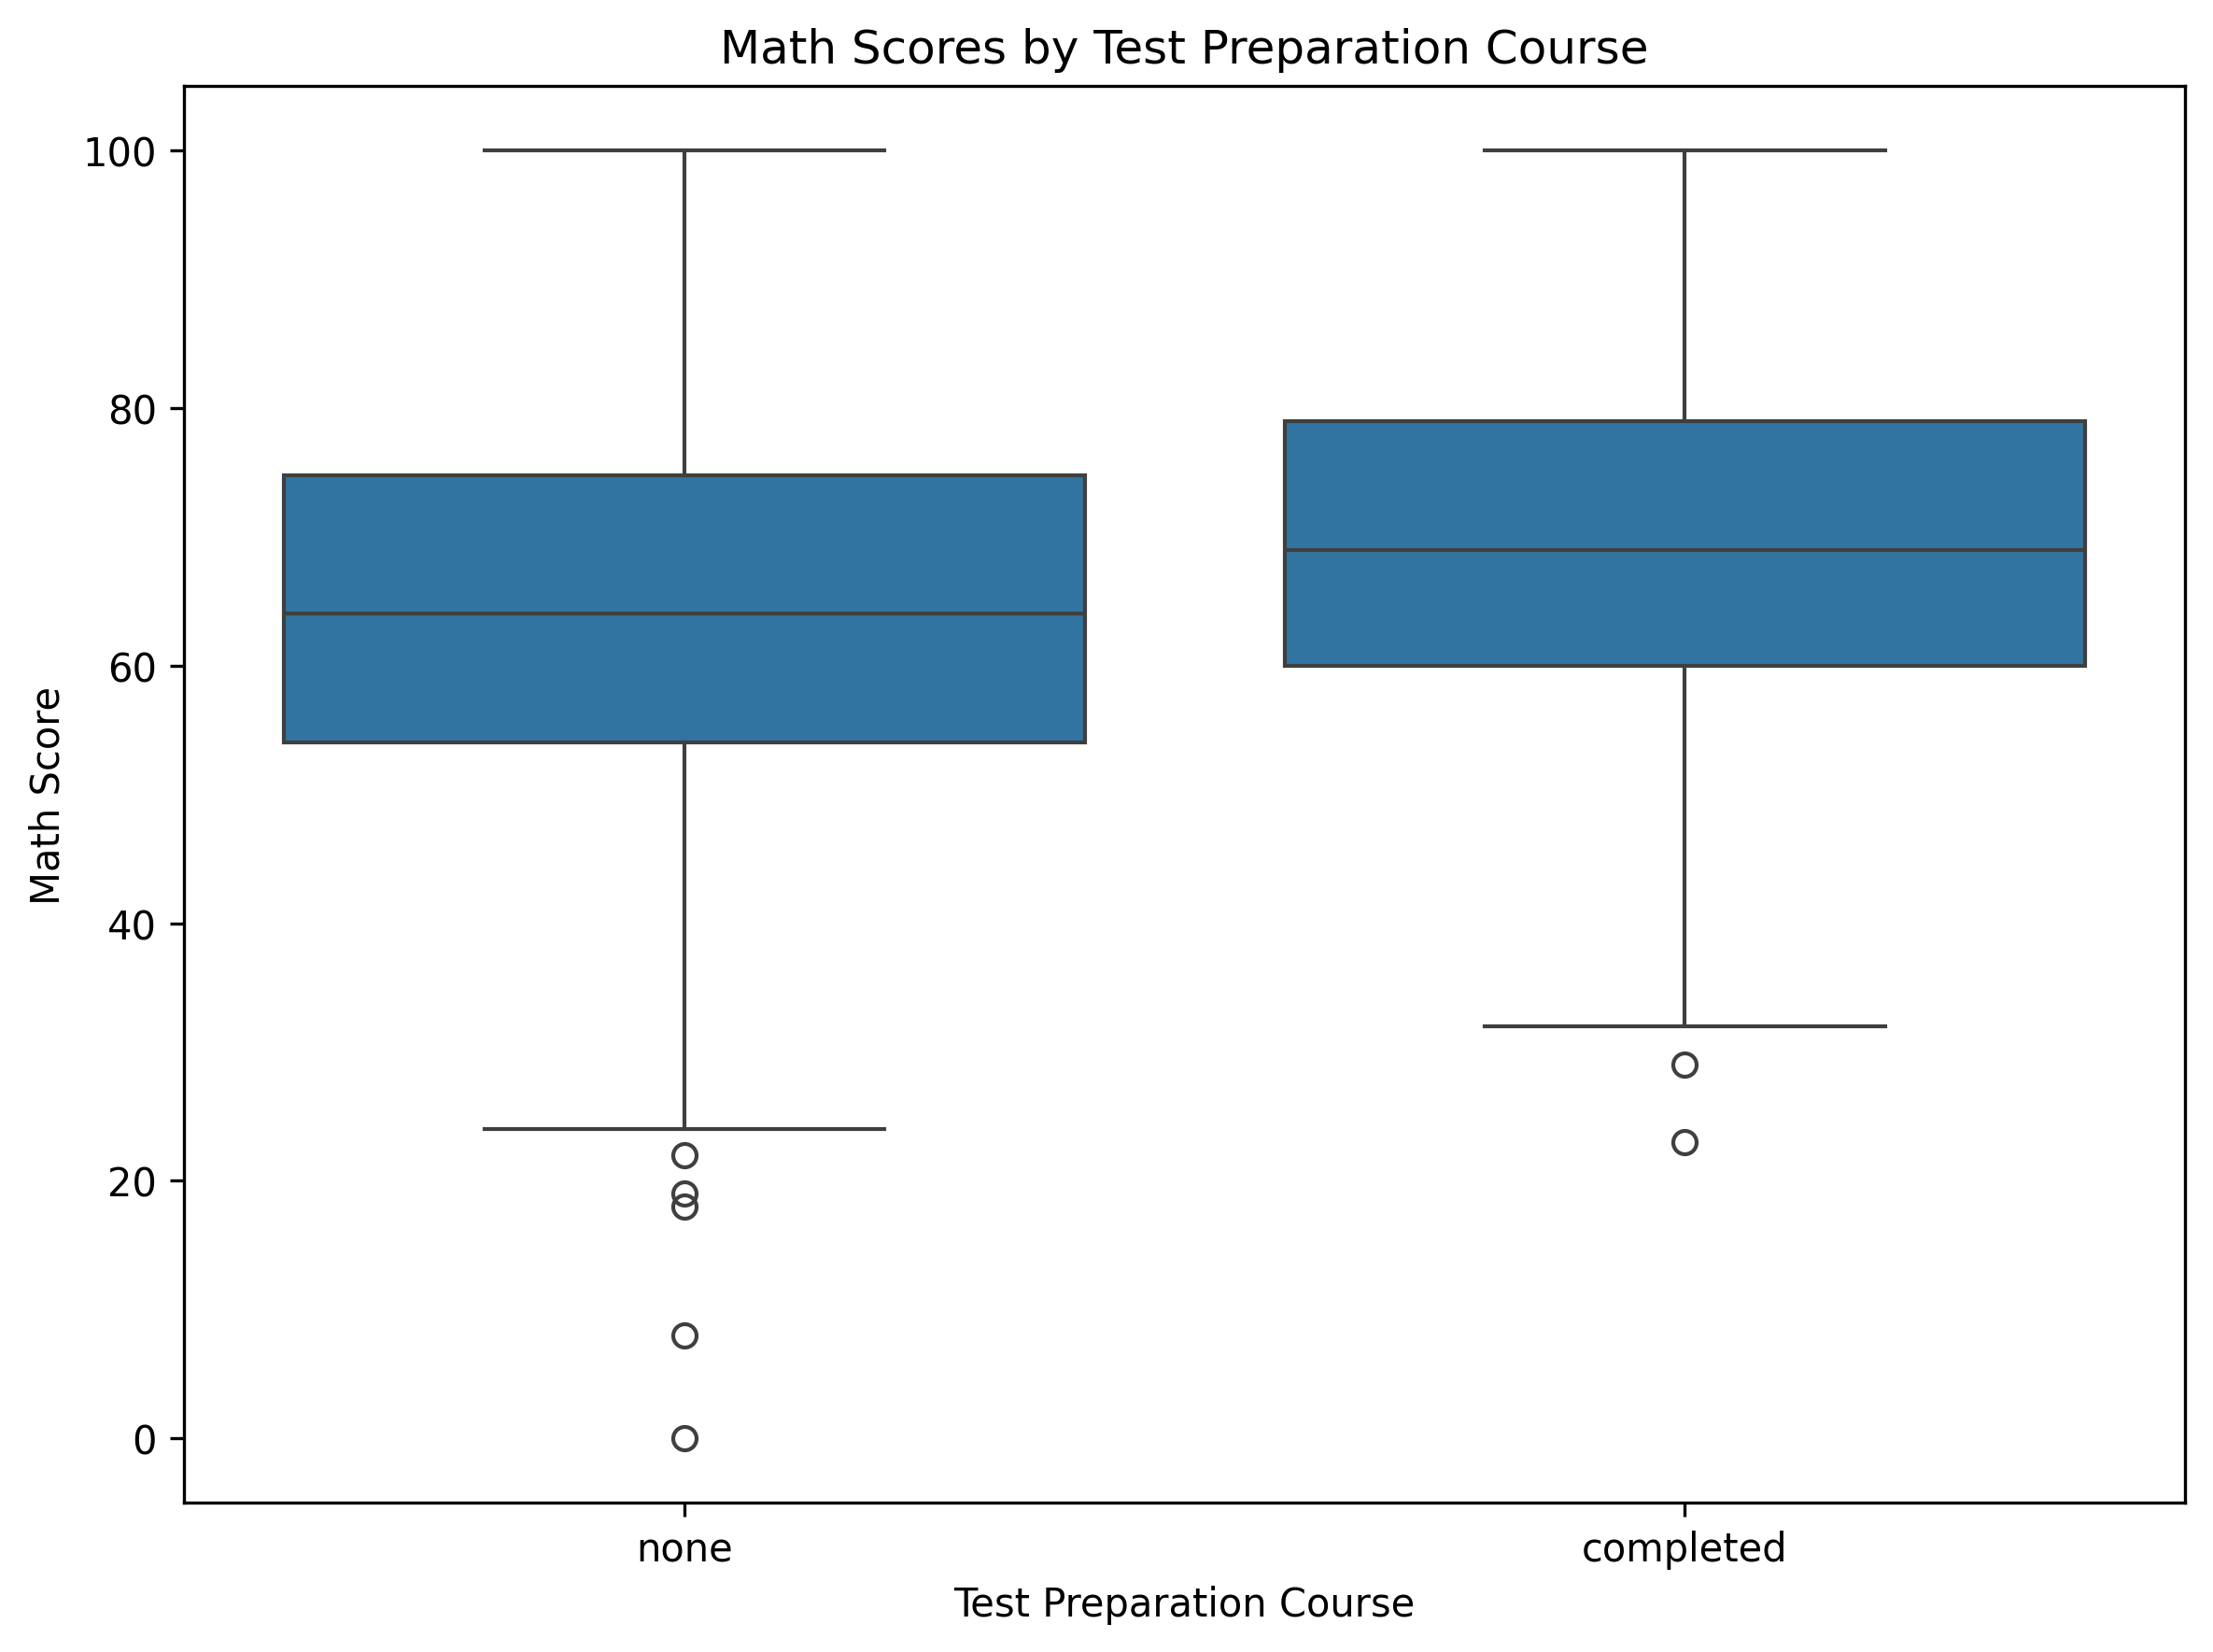

In [18]:
plt.figure(figsize=(8,6), dpi=300)

sns.boxplot(x="test_preparation_course", y="math_score", data=df1)
plt.title("Math Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.tight_layout()
plt.savefig("figures/V2_testprep_math.png")
plt.show()
plt.close()

In [19]:
df1["overall_avg"] = df1[["math_score", "reading_score", "writing_score"]].mean(axis=1)

From the grouped bar chart, it is clear that the overall average score of students who get standard lunch is higher compared to those who get free/reduced lunch. There is a performance gap between the two sets of students. Given that lunch programs are a determinant of socioeconomic status, it is likely that there are differences in resources. Students who get free/reduced lunch perform lower on average. Correlation is shown in this graph but not causation. There is slight difference of the average score if the students are taking reduced lunch, so we can decide that standard lunch is better to have and we do not need to stress students by reducing the lunch time.

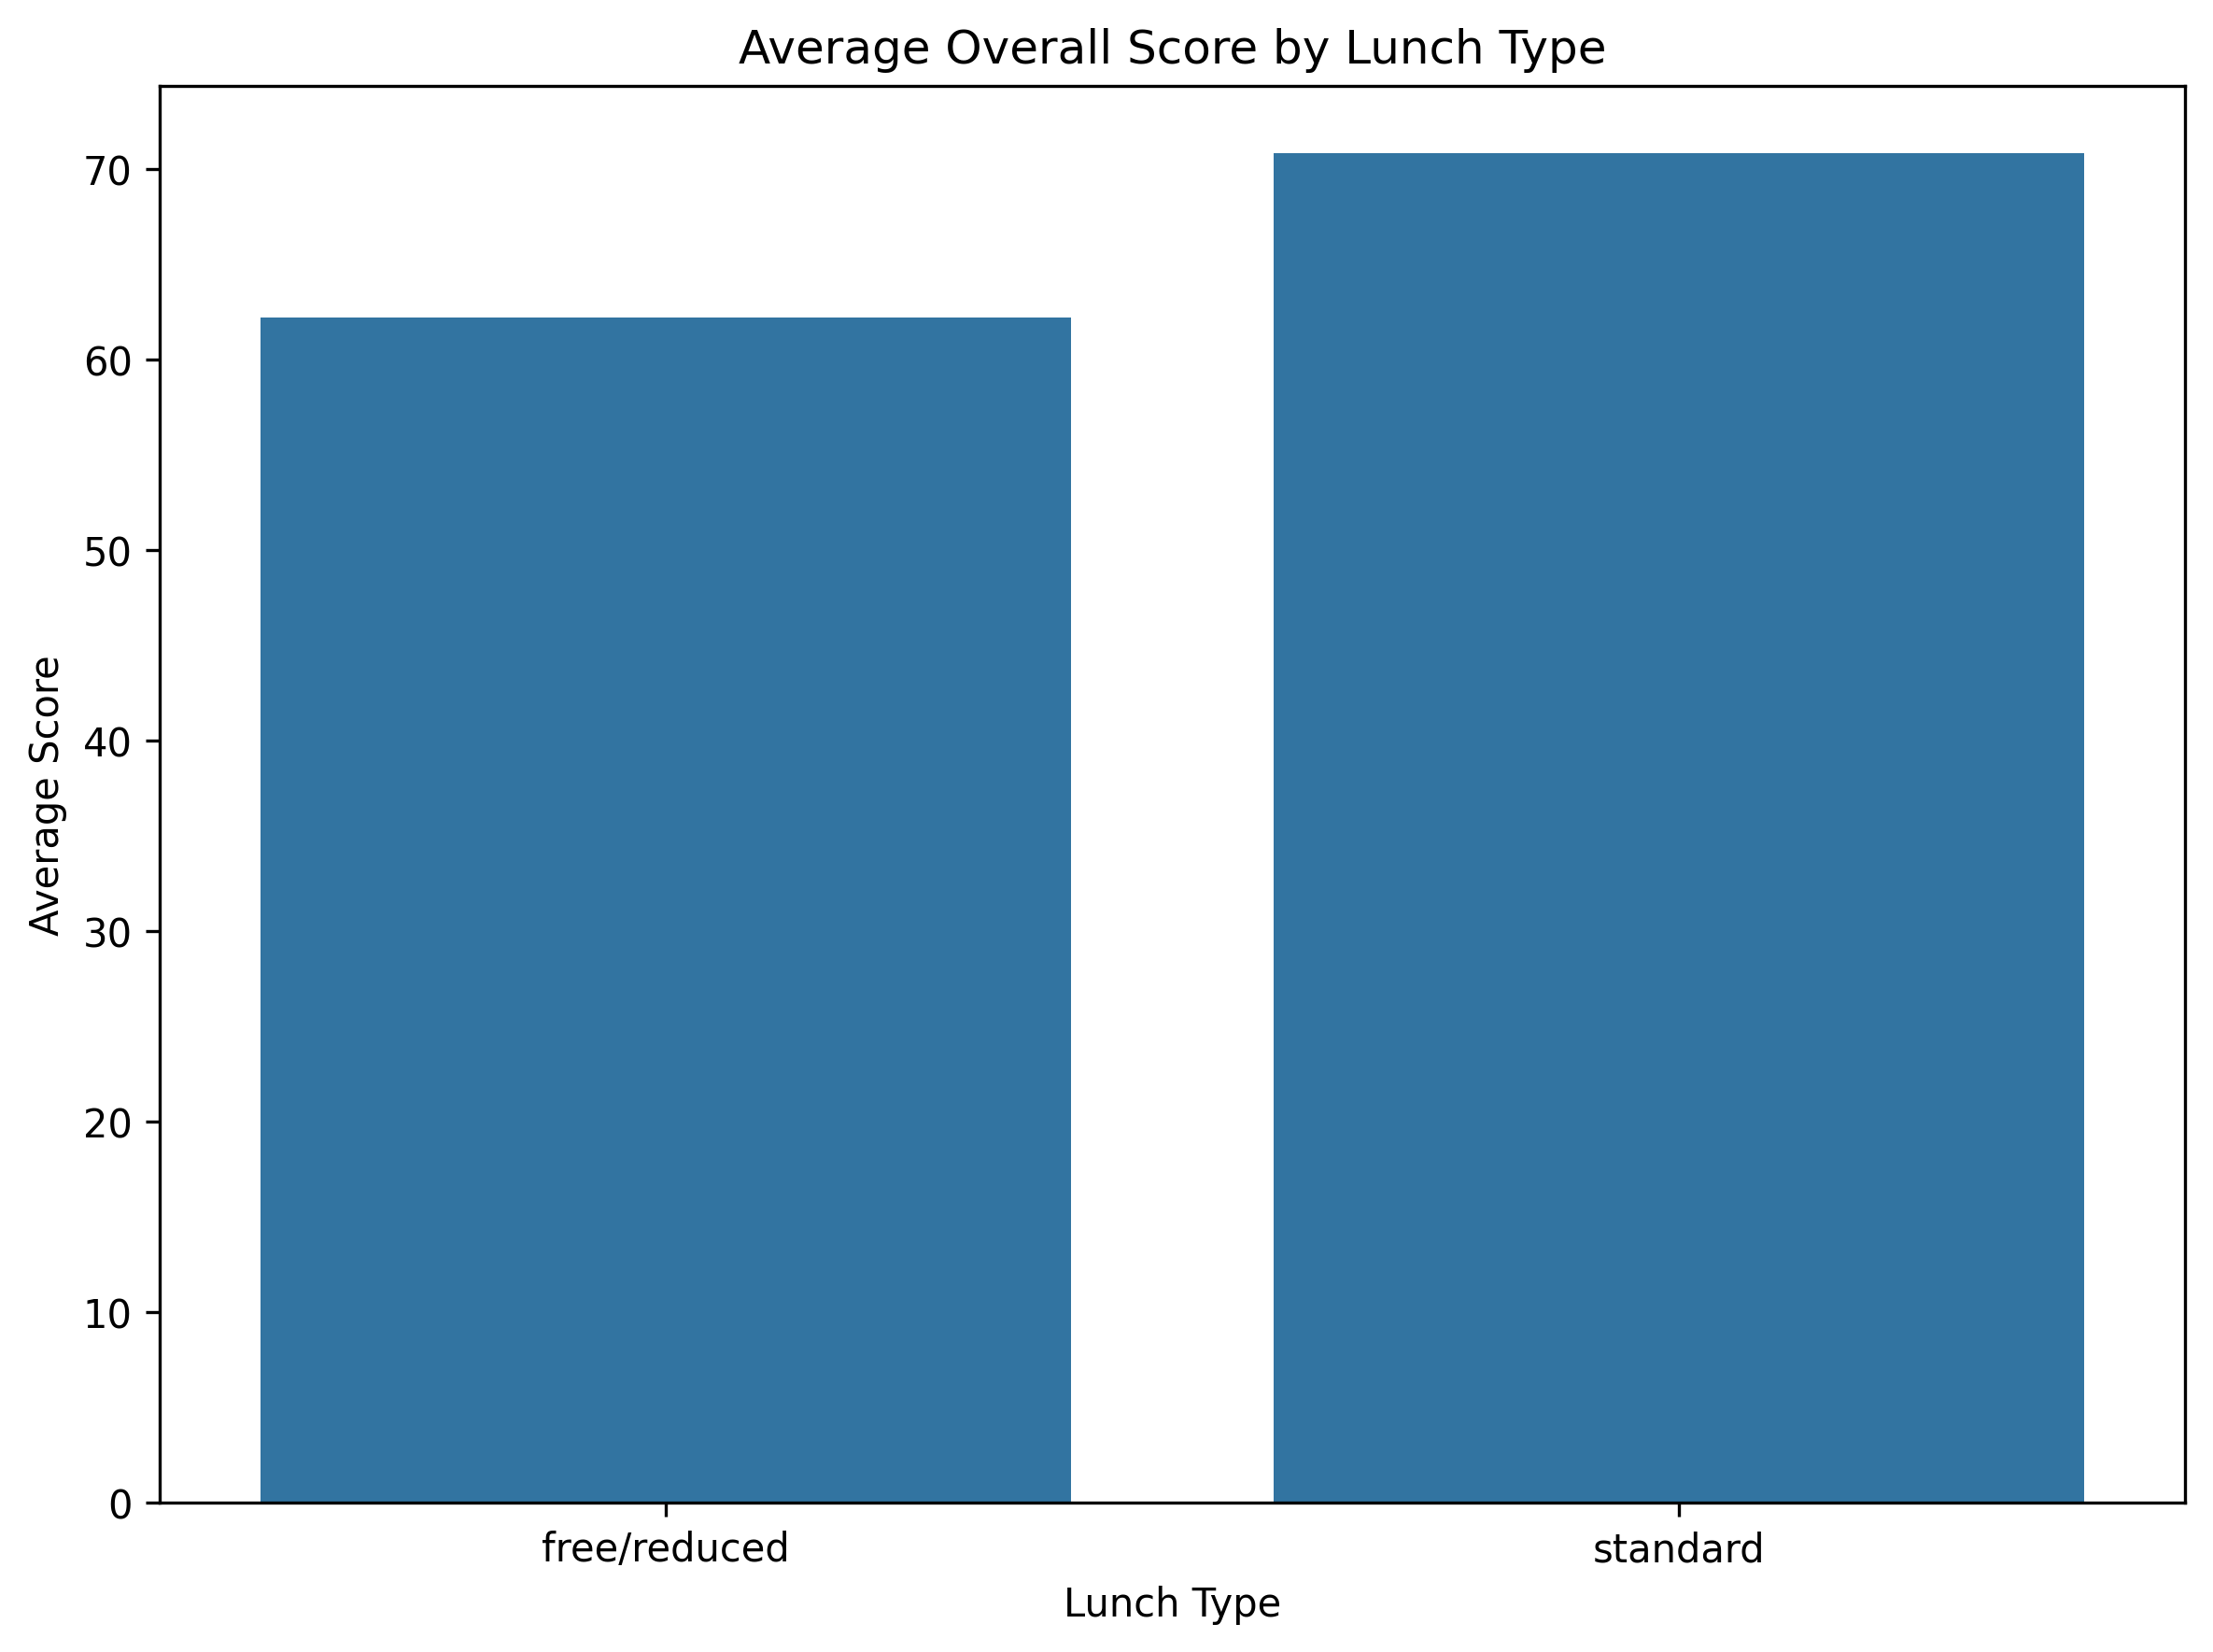

In [20]:
plt.figure(figsize=(8,6), dpi=300)

lunch_means = df1.groupby("lunch")["overall_avg"].mean().reset_index()
sns.barplot(x="lunch", y="overall_avg", data=lunch_means)

plt.title("Average Overall Score by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("figures/V3_lunch_avg.png")
plt.show()
plt.close()

The correlation heatmap indicates a strong positive correlation between math, reading, and writing scores. Reading and writing scores always have the highest correlation, which shows that students performing well in reading are likely to perform well in writing as well. Math scores are positively correlated with reading and writing scores but not as strongly. The high correlation coefficient values indicate that the performance of the subjects is correlated. This shows that students performing well in one subject are likely to perform well in other subjects as well.

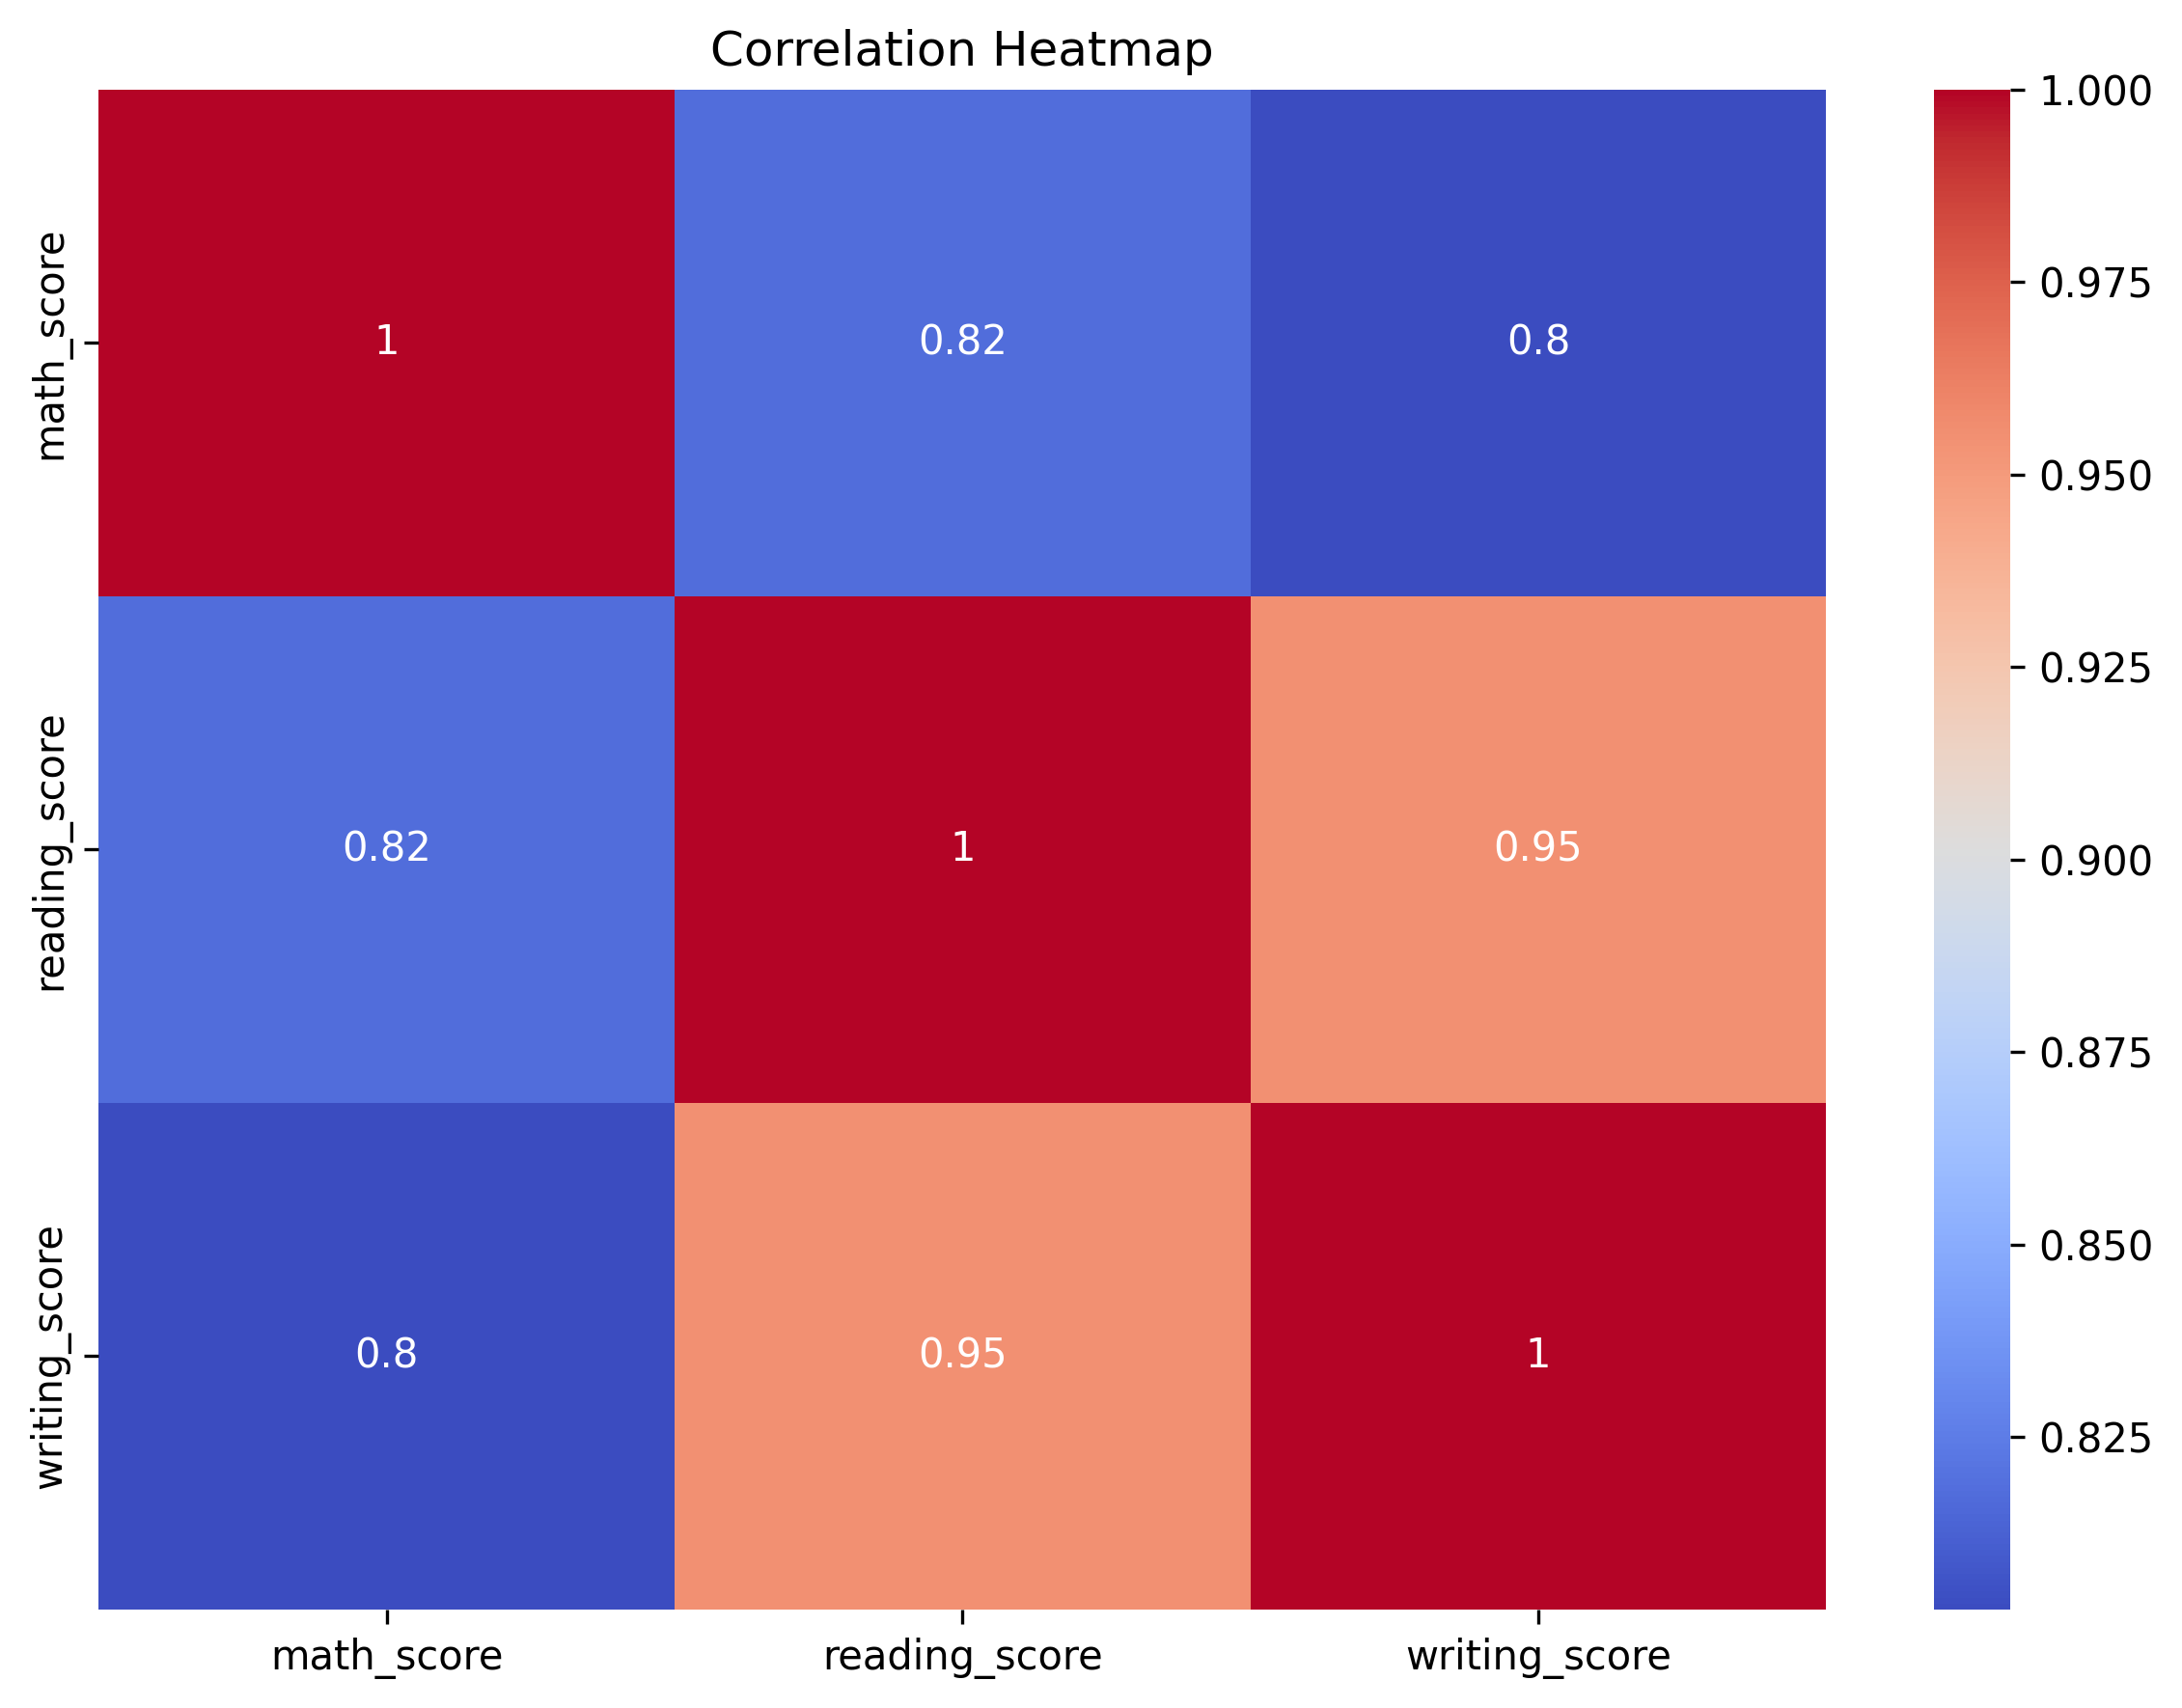

In [21]:
plt.figure(figsize=(8,6), dpi=300)
corr = df1[["math_score","reading_score","writing_score"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/V4_corr_heatmap.png")
plt.show()
plt.close()

From the scatter plot provided, it is evident that there is a strong positive correlation between the reading and math scores. This is because as the reading scores are higher, the math scores are also higher. The regression lines for the two groups preparing for the tests are positive, indicating a linear correlation. From the regression lines, it is evident that the students who prepared for the tests are performing better in higher score ranges. The slope for the completed group seems a bit higher. This suggests a strong alignment in performance. Nevertheless, it is evident that there is a strong correlation between the reading and math performance.

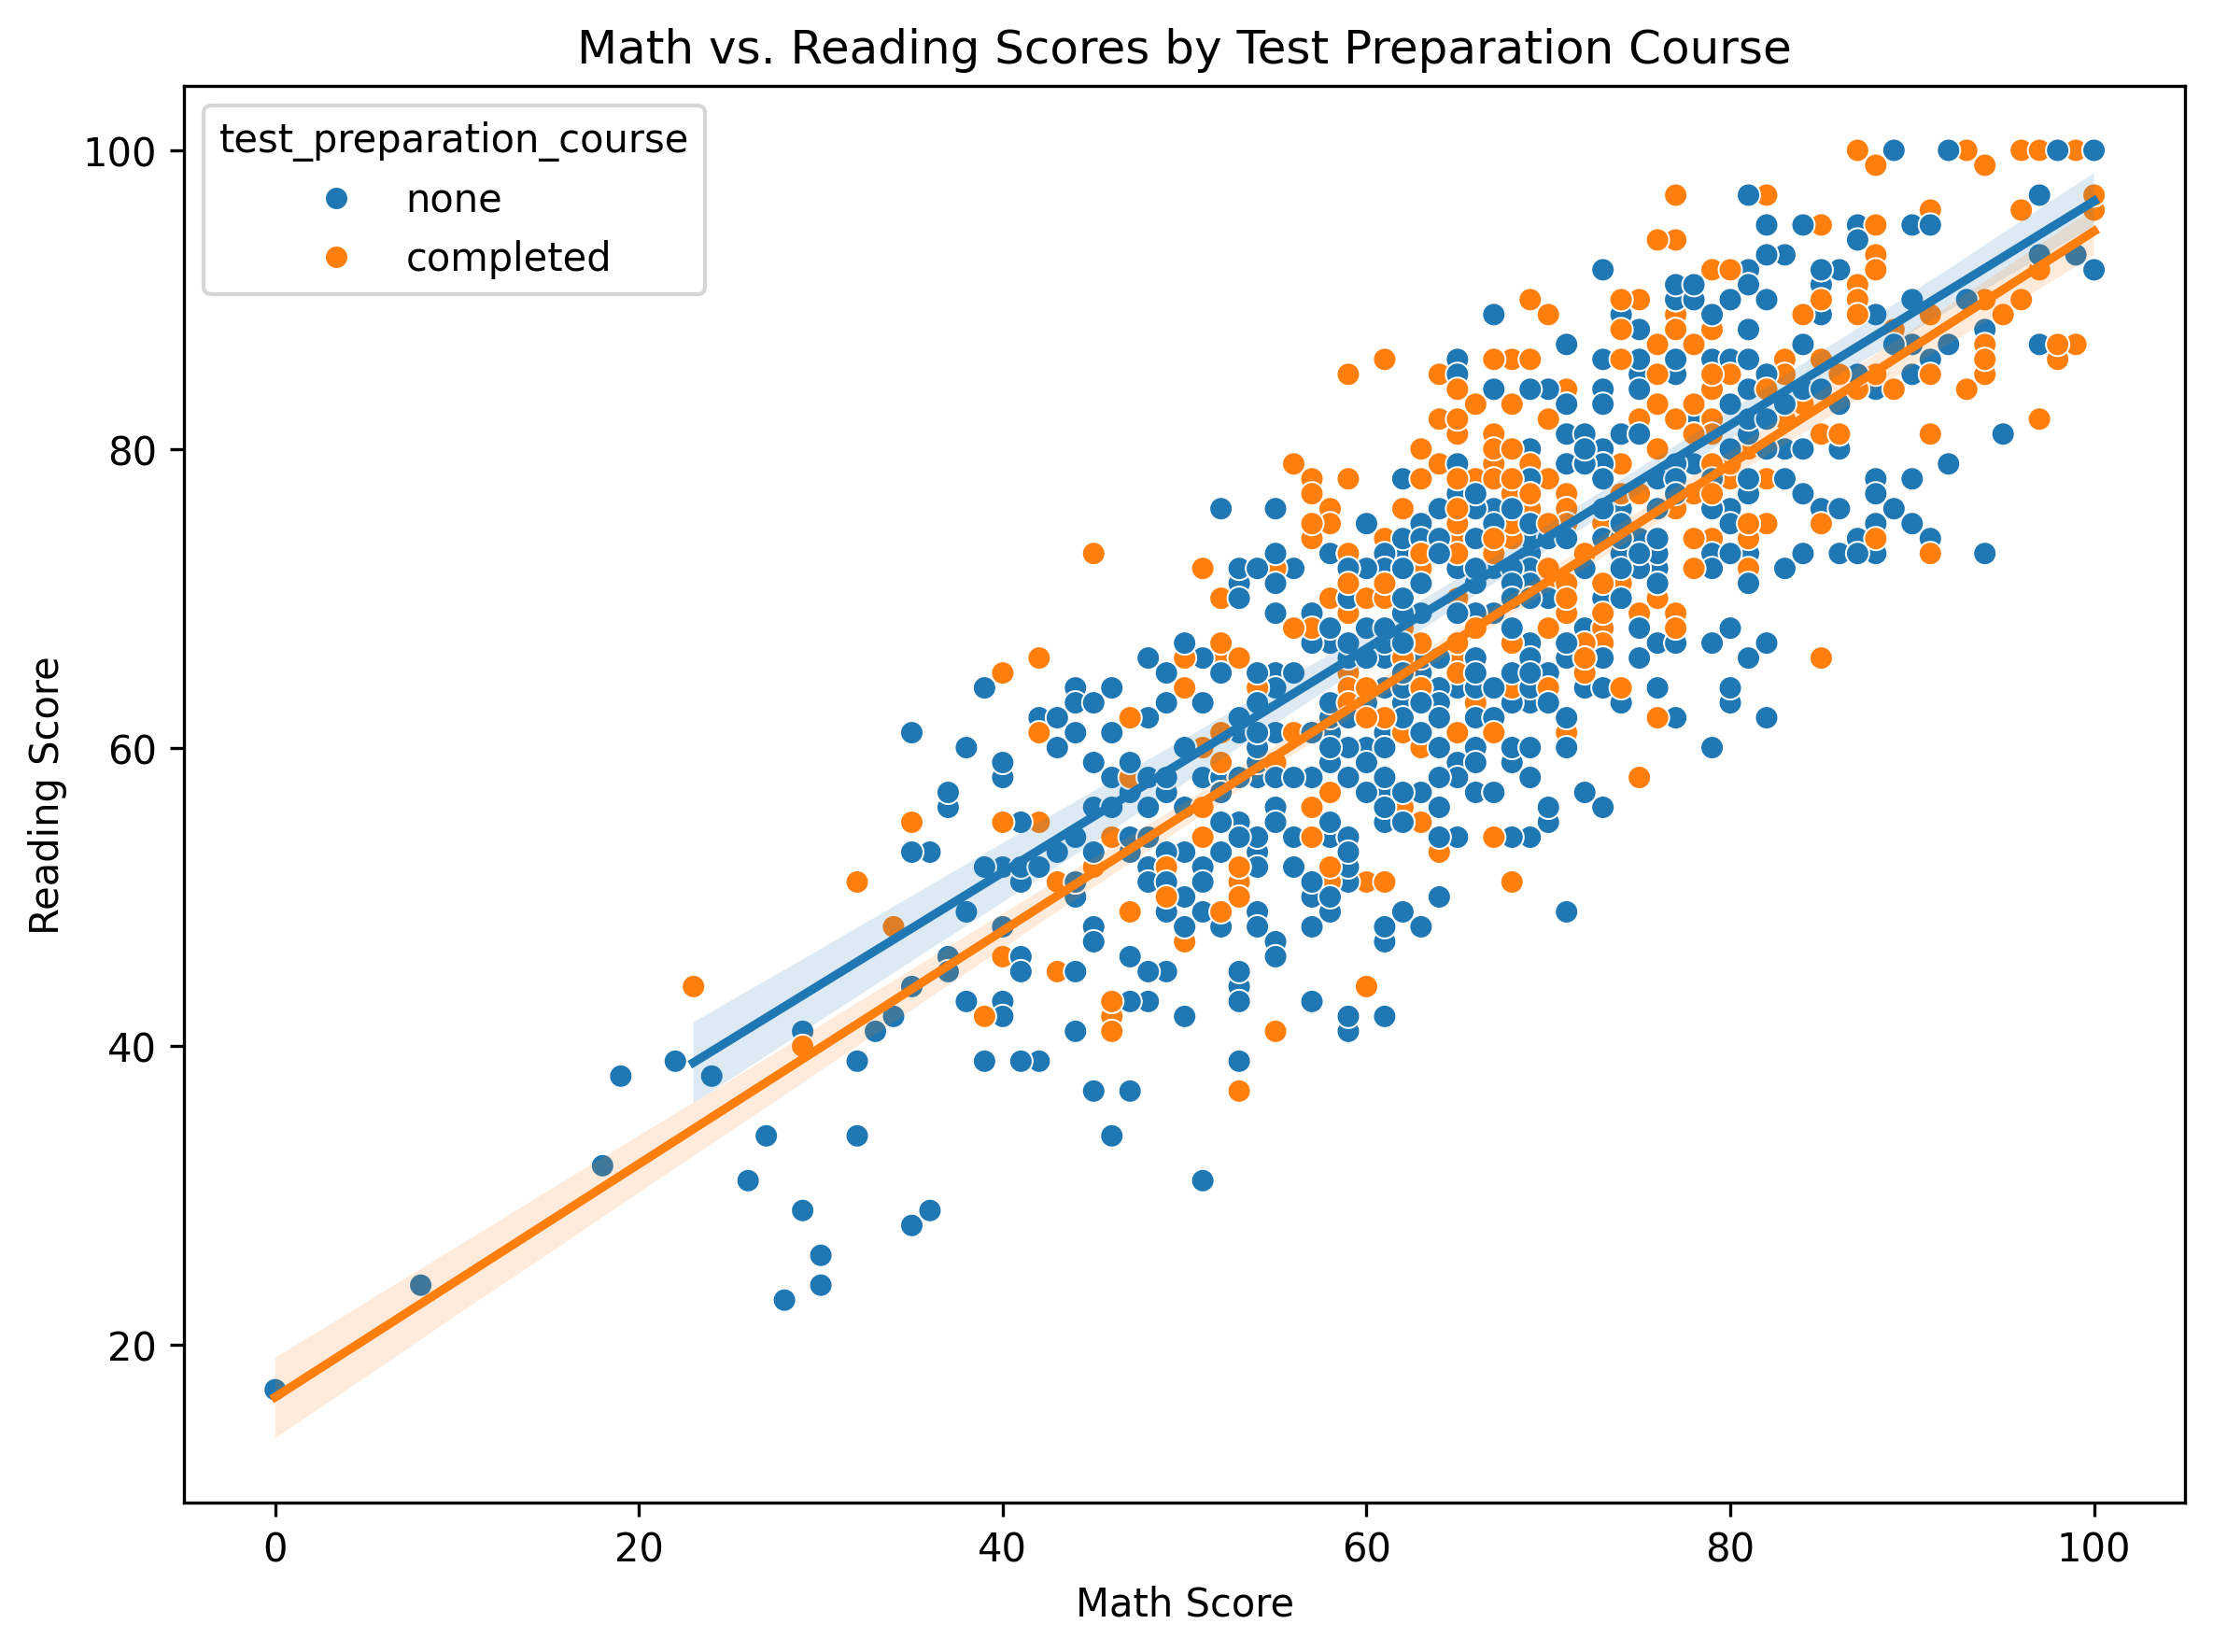

In [22]:
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(x="math_score", y="reading_score", hue= "test_preparation_course", data=df1)
sns.regplot(x="math_score", y="reading_score", data=df1[df1['test_preparation_course']=='completed'], scatter=False)
sns.regplot(x="math_score", y="reading_score", data=df1[df1['test_preparation_course']=='none'], scatter=False)
plt.title("Math vs. Reading Scores by Test Preparation Course")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.tight_layout()
plt.savefig("figures/V5_testprep_math_vs_reading.png")
plt.show()
plt.close()